### 1. Getting Setup

In [1]:
import torch 
import torchvision
print(f"Torch version: {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")

Torch version: 2.11.0+cu128
TorchVision version: 0.26.0+cu128


In [2]:
import torch 
import torchvision
from torchvision import transforms
from torch import nn 
import matplotlib.pyplot as plt 

# try to import summary from torchinfo else if not found it will download and import 
try: 
    from torchinfo import summary
except:
    print(f"[INFO] Couldn't find summary...Downloading....")
    !pip install -q torchinfo
    from torchinfo import summary
    
""" try to import data_setup, engine from going_modular.going_modular 
else if not found it will clone github repository, then move pytorch/going_modular(all files)
into current working directory then it will remove pytorch file and import data_setup, engine
"""
try: 
    from going_modular.going_modular import data_setup, engine
except: 
    print(f"[INFO] Couldn't find going_modular...Downloading...")
    !git clone https://github.com/Abisheklimbu/pytorch
    !mv pytorch/going_modular . 
    !rm -rf pytorch 
    from going_modular.going_modular import data_setup, engine

[INFO] Couldn't find summary...Downloading....
[INFO] Couldn't find going_modular...Downloading...
Cloning into 'pytorch'...
remote: Enumerating objects: 2713, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 2713 (delta 7), reused 10 (delta 2), pack-reused 2691 (from 2)
Receiving objects: 100% (2713/2713), 319.58 MiB | 28.61 MiB/s, done.
Resolving deltas: 100% (266/266), done.
Updating files: 100% (3439/3439), done.


In [3]:
# device agnostic code 
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
# set up seeds 
def set_seed(seed:int = 42):
    # set manual_seed 
    torch.manual_seed(seed)
    
    # set cuda manual_seed
    torch.cuda.manual_seed(seed)

set_seed

<function __main__.set_seed(seed: int = 42)>

### 2. Get Data

In [5]:
from pathlib import Path 
import requests
import zipfile
import os 

def download_data(source: str, 
                  destination: str,
                  remove_source: bool = True) -> Path:
    """Downloads a zipped dataset from source and unzips to destination.

    Args:
        source (str): A link to a zipped file containing data.
        destination (str): A target directory to unzip data to.
        remove_source (bool): Whether to remove the source after downloading and extracting.
    
    Returns:
        pathlib.Path to downloaded data.
    
    Example usage:
        download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                      destination="pizza_steak_sushi")
    """
    # Setup path to data folder
    data_path = Path("data/")
    image_path = data_path / destination

    # If the image folder doesn't exist, download it and prepare it... 
    if image_path.is_dir():
        print(f"[INFO] {image_path} directory exists, skipping download.")
    else:
        print(f"[INFO] Did not find {image_path} directory, creating one...")
        image_path.mkdir(parents=True, exist_ok=True)
        
        # Download pizza, steak, sushi data
        target_file = Path(source).name
        with open(data_path / target_file, "wb") as f:
            request = requests.get(source)
            print(f"[INFO] Downloading {target_file} from {source}...")
            f.write(request.content)

        # Unzip pizza, steak, sushi data
        with zipfile.ZipFile(data_path / target_file, "r") as zip_ref:
            print(f"[INFO] Unzipping {target_file} data...") 
            zip_ref.extractall(image_path)

        # Remove .zip file
        if remove_source:
            os.remove(data_path / target_file)
    
    return image_path

In [6]:
# Download pizza, steak, sushi images from GitHub
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                           destination="pizza_steak_sushi")
image_path

[INFO] Did not find data/pizza_steak_sushi directory, creating one...
[INFO] Downloading pizza_steak_sushi.zip from https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip...
[INFO] Unzipping pizza_steak_sushi.zip data...


PosixPath('data/pizza_steak_sushi')

In [7]:
train_dir = image_path/"train"
test_dir = image_path/"test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

### 3. Get Dataset and DataLoader

In [8]:
# Create image size (from Table 3 in the ViT paper)
IMG_SIZE = 224

# Create transform pipeline manually
manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
print(f"Manually created transforms: {manual_transforms}")

Manually created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [9]:
from going_modular.going_modular import data_setup, engine

In [ ]:
# Set the batch size
BATCH_SIZE = 32 

# Create data loaders
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms, # use manually created transforms
    batch_size=BATCH_SIZE
)

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7f22f9b501a0>,
 ['pizza', 'steak', 'sushi'])

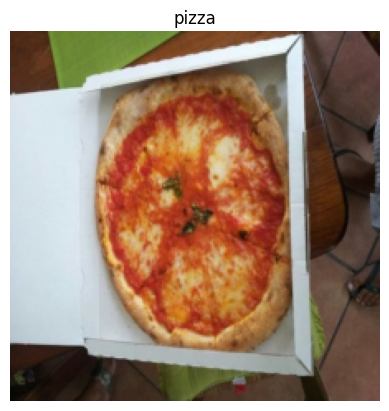

In [11]:
# Get a batch of images
image_batch, label_batch = next(iter(train_dataloader))

# Get a single image from the batch
image, label = image_batch[0], label_batch[0]

# View the batch shapes
image.shape, label
# Plot image with matplotlib
plt.imshow(image.permute(1, 2, 0)) # color_channels, height, width] -> [height, width, color_channels]
plt.title(class_names[label])
plt.axis(False);

### 4. Replicating ViT Paper 

In [ ]:
# Create example values
height = 224 
width = 224 
color_channels = 3 
patch_size = 16 

# Calculate N (number of patches)
number_of_patches = int((height * width) / patch_size**2)
print(f"Number of patches (N) with image height (H={height}), width (W={width}) and patch size (P={patch_size}): {number_of_patches}")

Number of patches (N) with image height (H=224), width (W=224) and patch size (P=16): 196


In [ ]:
# Input shape (this is the size of a single image)
embedding_layer_input_shape = (height, width, color_channels)

# Output shape
embedding_layer_output_shape = (number_of_patches, patch_size**2 * color_channels)

print(f"Input shape (single 2D image): {embedding_layer_input_shape}")
print(f"Output shape (single 2D image flattened into patches): {embedding_layer_output_shape}")

Input shape (single 2D image): (224, 224, 3)
Output shape (single 2D image flattened into patches): (196, 768)


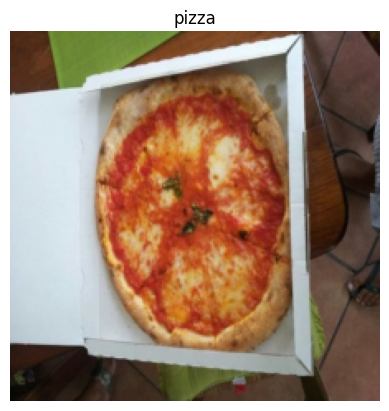

In [14]:
# Turning single image into patches 
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis("off");

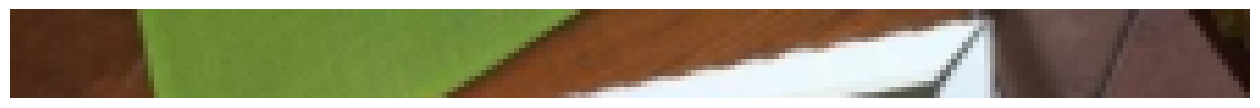

In [15]:
image_permuted = image.permute(1,2,0)
patch_size = 16 
plt.figure(figsize=(patch_size, patch_size))
plt.imshow(image_permuted[:patch_size, :, :])
plt.axis(False);


Number of patches per row: 14.0
Patch size: 16 pixels x 16 pixels


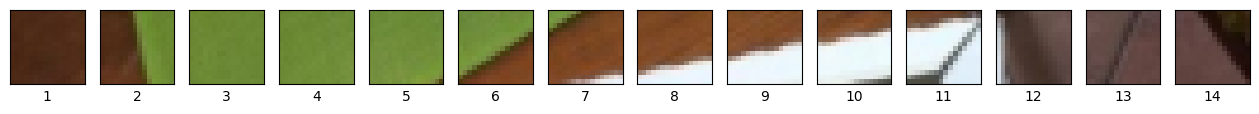

In [16]:
# Patches for top row of image 
img_size = 224
patch_size = 16
num_patches = img_size / patch_size
assert img_size % patch_size == 0

print(f"Number of patches per row: {num_patches}\nPatch size: {patch_size} pixels x {patch_size} pixels")

fig, ax = plt.subplots(nrows=1, 
                       ncols=img_size//patch_size, 
                       figsize=(patch_size, patch_size), 
                       sharex=True, 
                       sharey=True)

for i,patch in enumerate(range(0, img_size, patch_size)):
    ax[i].imshow(image_permuted[:patch_size, patch:patch + patch_size, :])
    ax[i].set_xlabel(i+1)
    ax[i].set_xticks([])
    ax[i].set_yticks([])

Number of patches per row: 14.0
Total patches: 196.0
Patch size: 16 pixels x 16 pixels


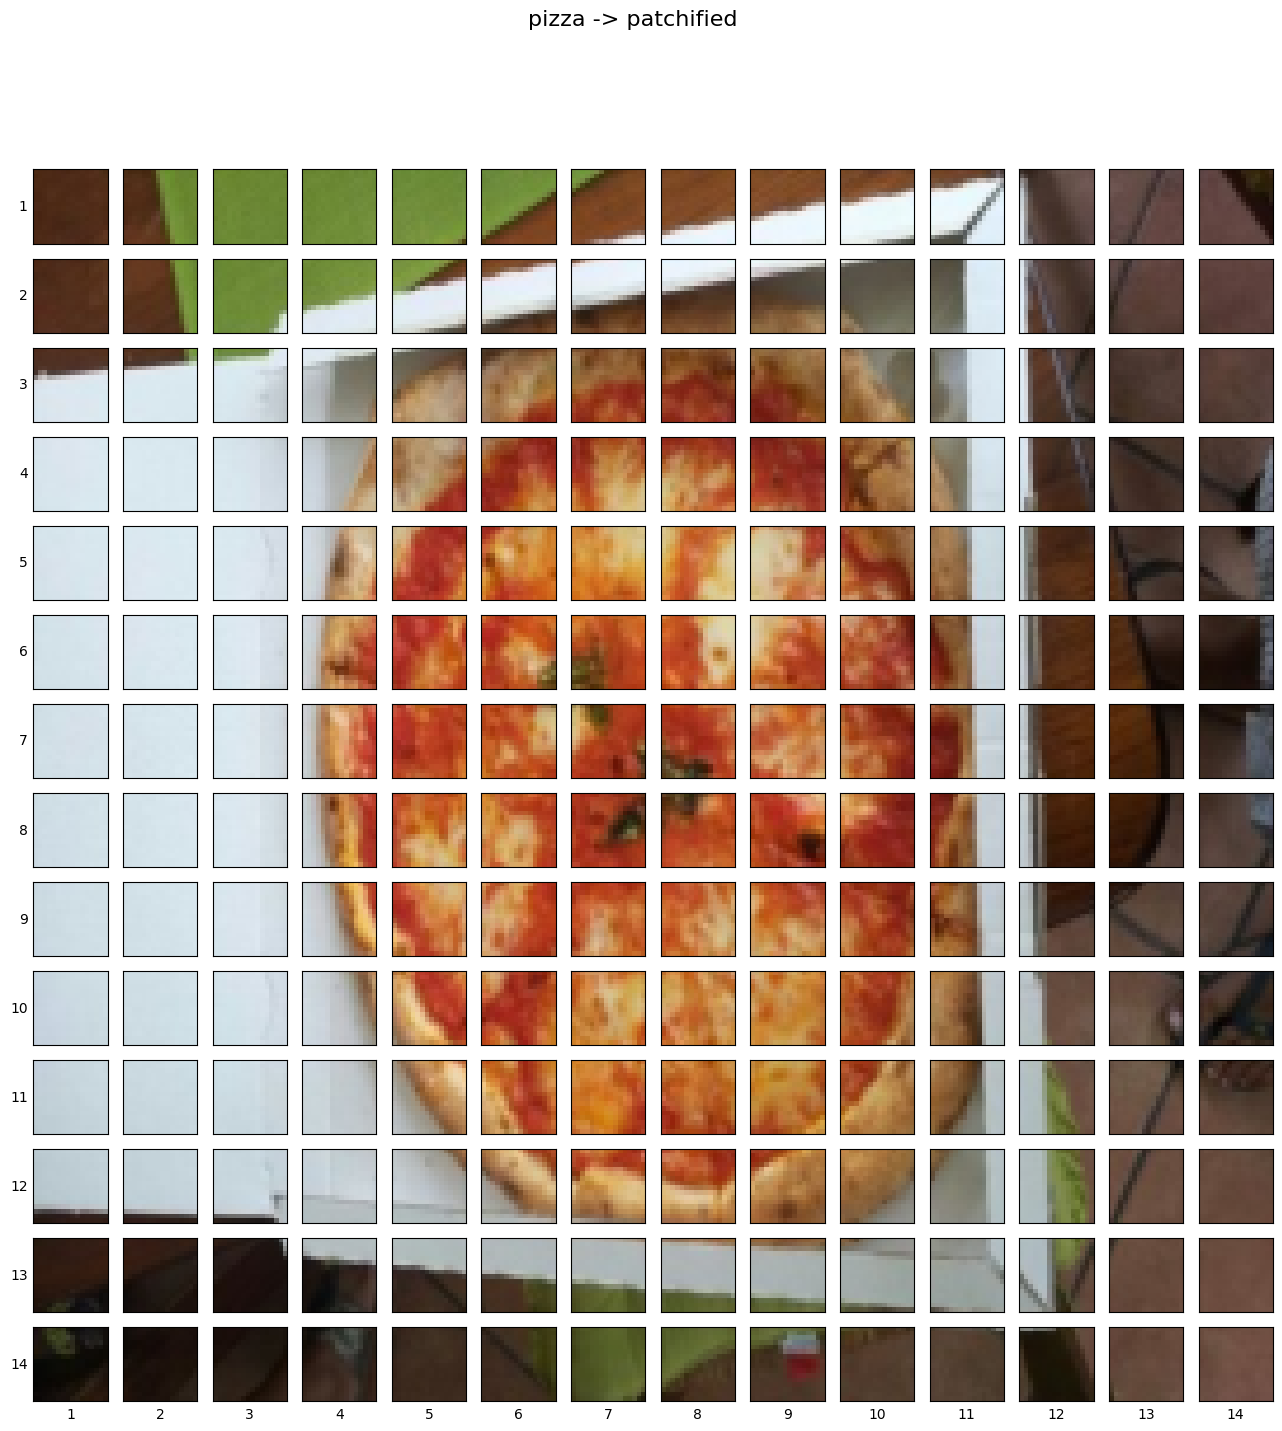

In [17]:
# Patches for whole image 
img_size = 224
patch_size = 16
num_patches = img_size / patch_size
assert img_size % patch_size == 0

print(f"Number of patches per row: {num_patches}\nTotal patches: {num_patches*num_patches}\nPatch size: {patch_size} pixels x {patch_size} pixels")

fig, ax = plt.subplots(nrows=img_size//patch_size,  
                       ncols=img_size//patch_size, 
                       figsize=(patch_size, patch_size), 
                       sharex=True, 
                       sharey=True)

for i,patch_height in enumerate(range(0, img_size, patch_size)):
    for j,patch_width in enumerate(range(0, img_size, patch_size)):
        ax[i,j].imshow(image_permuted[patch_height:patch_height+patch_size, patch_width:patch_width+patch_size, :])
        ax[i,j].set_ylabel(i+1, rotation="horizontal", horizontalalignment="right", verticalalignment="center")
        ax[i,j].set_xlabel(j+1)
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])
        ax[i,j].label_outer()
        
fig.suptitle(f"{class_names[label]} -> patchified", fontsize=16)
plt.show()
    

#### CREATING IMAGE PATCHES WITH torch.nn.Conv2d()

In [18]:
from torch import nn
patch_size = 16 
conv2d = nn.Conv2d(
    in_channels=3, 
    out_channels=768, 
    kernel_size=patch_size, 
    stride=patch_size, 
    padding=0
)

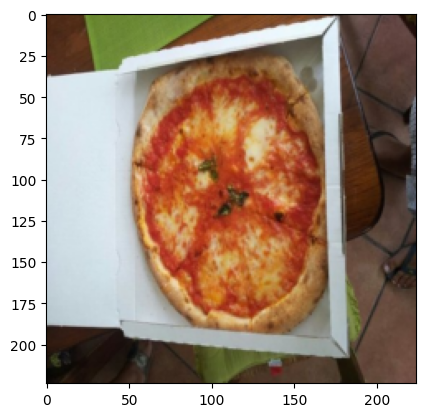

In [19]:
plt.imshow(image_permuted)

In [20]:
img_out_of_conv2d = conv2d(image.unsqueeze(0))
print(img_out_of_conv2d.shape)

torch.Size([1, 768, 14, 14])


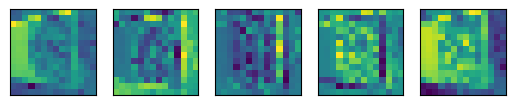

In [21]:
# plotting random 5 convolutional feature maps 
import random 
random_idx = random.sample(range(0,768), k=5)
fig, ax = plt.subplots(nrows=1, 
                       ncols=5)

for i, idx in enumerate(random_idx):
    img_conv_feature_map = img_out_of_conv2d[:, idx, :, :]
    ax[i].imshow(img_conv_feature_map.squeeze().detach().numpy())
    ax[i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

In [22]:
# Get single feature map in tensor form 
single_feature_map = img_out_of_conv2d[:,0,:,:]
single_feature_map, single_feature_map.requires_grad

(tensor([[[ 0.0969,  0.2348,  0.2574,  0.2593,  0.2726,  0.2626,  0.1216,
            0.0308,  0.2712,  0.7405,  0.9617,  0.2304,  0.1719,  0.1425],
          [ 0.1169,  0.1271,  0.2450,  0.3140,  0.6958,  1.0127,  0.4458,
           -0.0987, -0.1123,  0.1398,  0.5063,  0.1766,  0.1455,  0.1567],
          [ 0.7896,  0.8090,  0.6660,  0.2333,  0.3202,  0.4511,  0.2890,
            0.2025,  0.1597,  0.3383,  0.5044,  0.2794,  0.1347,  0.1653],
          [ 0.5828,  0.5888,  0.5770,  0.4662,  0.3254,  0.2178,  0.3640,
            0.4323,  0.1561,  0.2004,  0.4729,  0.2242,  0.0887,  0.1124],
          [ 0.5808,  0.5878,  0.5855,  0.4298,  0.1991,  0.3338,  0.4218,
            0.3694,  0.5075,  0.1470,  0.4951,  0.1816,  0.0544,  0.2168],
          [ 0.5684,  0.5838,  0.5777,  0.3540,  0.2902,  0.4253,  0.1191,
            0.4145,  0.2658,  0.2820,  0.3744,  0.1966,  0.0414, -0.0432],
          [ 0.5674,  0.5787,  0.5849,  0.4782,  0.1734,  0.3265,  0.2871,
            0.1888,  0.2574,  0.

In [ ]:
single_feature_map.shape

torch.Size([1, 14, 14])

#### FLATTENING THE PATCH EMBEDDINGS WITH torch.nn.Flatten()

In [24]:
flatten = nn.Flatten(start_dim=2, # feature_map_height
                     end_dim=3) # feature_map_width
                     

torch.Size([3, 224, 224])


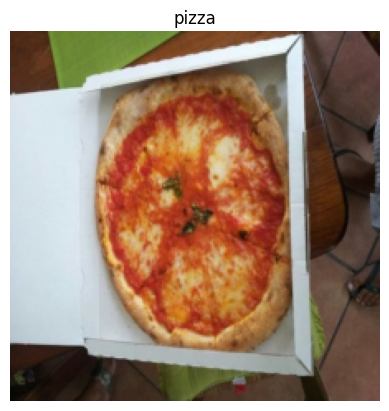

In [25]:
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
print(image.shape)
plt.axis("off");

In [26]:
img_out_of_conv = conv2d(image.unsqueeze(0))
img_out_of_conv.shape

torch.Size([1, 768, 14, 14])

In [27]:
img_out_of_flattened = flatten(img_out_of_conv)
img_out_of_flattened.shape

torch.Size([1, 768, 196])

In [28]:
img_out_of_conv_flattened_reshaped = img_out_of_flattened.permute(0,2,1)
img_out_of_conv_flattened_reshaped.shape

torch.Size([1, 196, 768])

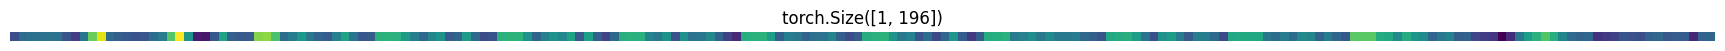

In [29]:
single_flattened_feature_map = img_out_of_conv_flattened_reshaped[:, :, 0]
plt.figure(figsize=(22,22))
plt.imshow(single_flattened_feature_map.detach().numpy())
plt.title(single_flattened_feature_map.shape)
plt.axis("off");

In [30]:
single_flattened_feature_map, single_flattened_feature_map.requires_grad

(tensor([[ 0.0969,  0.2348,  0.2574,  0.2593,  0.2726,  0.2626,  0.1216,  0.0308,
           0.2712,  0.7405,  0.9617,  0.2304,  0.1719,  0.1425,  0.1169,  0.1271,
           0.2450,  0.3140,  0.6958,  1.0127,  0.4458, -0.0987, -0.1123,  0.1398,
           0.5063,  0.1766,  0.1455,  0.1567,  0.7896,  0.8090,  0.6660,  0.2333,
           0.3202,  0.4511,  0.2890,  0.2025,  0.1597,  0.3383,  0.5044,  0.2794,
           0.1347,  0.1653,  0.5828,  0.5888,  0.5770,  0.4662,  0.3254,  0.2178,
           0.3640,  0.4323,  0.1561,  0.2004,  0.4729,  0.2242,  0.0887,  0.1124,
           0.5808,  0.5878,  0.5855,  0.4298,  0.1991,  0.3338,  0.4218,  0.3694,
           0.5075,  0.1470,  0.4951,  0.1816,  0.0544,  0.2168,  0.5684,  0.5838,
           0.5777,  0.3540,  0.2902,  0.4253,  0.1191,  0.4145,  0.2658,  0.2820,
           0.3744,  0.1966,  0.0414, -0.0432,  0.5674,  0.5787,  0.5849,  0.4782,
           0.1734,  0.3265,  0.2871,  0.1888,  0.2574,  0.2662,  0.3574,  0.1802,
           0.097

#### TURNING ViT PATCH EMBEDDINGS LAYER INTO PYTORCH MODULE 

##### EQUATION 1 : $\mathbf{z}_0=\left[\mathbf{x}_{\text {class }} ; \mathbf{x}_p^1 \mathbf{E} ; \mathbf{x}_p^2 \mathbf{E} ; \cdots ; \mathbf{x}_p^N \mathbf{E}\right]+\mathbf{E}_{\text {pos }}, \quad \mathbf{E} \in \mathbb{R}^{\left(P^2 \cdot C\right) \times D}, \mathbf{E}_{\text {pos }} \in \mathbb{R}^{(N+1) \times D}$

##### patch embedding class

In [ ]:
class PatchEmbedding(nn.Module):
    def __init__(self, 
                 in_channels:int = 3, 
                 patch_size:int = 16, 
                 embedding_dimension:int = 768):
        super().__init__()
        
        # create layers to trun image into patches 
        self.patcher = nn.Conv2d(in_channels=in_channels, 
                                 out_channels=embedding_dimension, 
                                 kernel_size=patch_size, 
                                 stride=patch_size, 
                                 padding=0)
        
        # create layer to flatten patches into single dimension 
        self.flatten = nn.Flatten(start_dim=2, 
                                  end_dim=3)
        
    # define forward pass 
    def forward(self, x):
        image_resolution = x.shape[-1]
        assert image_resolution % patch_size ==0, f"Input image size must be divisible by patch size, image shape: {image_resolution.shape} patch_size: {patch_size}"
        x_patched = self.patcher(x)
        x_flattened = self.flatten(x_patched)
        return x_flattened.permute(0,2,1)

In [41]:
# Try it out on single image 
set_seed()
patchify = PatchEmbedding(in_channels=3, 
                          patch_size=16, 
                          embedding_dimension=768)
print(f"Input image shape: {image.unsqueeze(0).shape}")
patch_embeded_image = patchify(image.unsqueeze(0))
print(f"Output patch embedding shape: {patch_embeded_image.shape}")

Input image shape: torch.Size([1, 3, 224, 224])
Output patch embedding shape: torch.Size([1, 196, 768])


In [45]:
summary(PatchEmbedding(),
        input_size=rnd_input_img, 
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
PatchEmbedding (PatchEmbedding)          [1, 3, 224, 224]     [1, 196, 768]        --                   True
├─Conv2d (patcher)                       [1, 3, 224, 224]     [1, 768, 14, 14]     590,592              True
├─Flatten (flatten)                      [1, 768, 14, 14]     [1, 768, 196]        --                   --
Total params: 590,592
Trainable params: 590,592
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 115.76
Input size (MB): 0.60
Forward/backward pass size (MB): 1.20
Params size (MB): 2.36
Estimated Total Size (MB): 4.17

##### create class token embedding 

In [ ]:
print(patch_embeded_image)
print(f"patch_embeded_image shape: {patch_embeded_image.shape} -> [batch_size, number_of_patches, embedding_dimension]")

tensor([[[-0.2674,  0.0142, -0.0556,  ...,  0.1379, -0.1227,  0.0846],
         [-0.4077,  0.1739, -0.1067,  ...,  0.3055, -0.1673, -0.0046],
         [-0.4518,  0.1410, -0.1675,  ...,  0.3410, -0.2063,  0.1747],
         ...,
         [-0.1193,  0.0695, -0.0387,  ...,  0.0492, -0.1400,  0.1225],
         [-0.3580,  0.0564, -0.0879,  ...,  0.2149, -0.1619,  0.1377],
         [-0.4094,  0.0598, -0.0835,  ...,  0.2624, -0.1853,  0.1290]]],
       grad_fn=<PermuteBackward0>)
patch_embeded_image shape: torch.Size([1, 196, 768]) -> [batch_size, number_of_patches, embedding_dimension]


In [57]:
batch_size = patch_embeded_image.shape[0]
embedding_dimension = patch_embeded_image.shape[-1]

class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dimension), 
                           requires_grad = True)
print(class_token[:, :, :10])
print(f"Class token shape: {class_token.shape}")

tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]], grad_fn=<SliceBackward0>)
Class token shape: torch.Size([1, 1, 768])


In [58]:
patch_embedded_img_with_class_embedding = torch.cat((class_token, patch_embeded_image), 
                                                    dim=1)
print(patch_embedded_img_with_class_embedding)
print(f"patch_embedded_img_with_class_embedding shape: {patch_embedded_img_with_class_embedding.shape}")

tensor([[[ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
         [-0.2674,  0.0142, -0.0556,  ...,  0.1379, -0.1227,  0.0846],
         [-0.4077,  0.1739, -0.1067,  ...,  0.3055, -0.1673, -0.0046],
         ...,
         [-0.1193,  0.0695, -0.0387,  ...,  0.0492, -0.1400,  0.1225],
         [-0.3580,  0.0564, -0.0879,  ...,  0.2149, -0.1619,  0.1377],
         [-0.4094,  0.0598, -0.0835,  ...,  0.2624, -0.1853,  0.1290]]],
       grad_fn=<CatBackward0>)
patch_embedded_img_with_class_embedding shape: torch.Size([1, 197, 768])


##### creating position embeddings 


In [65]:
num_of_patches = int((height * width)/patch_size**2)
embedding_dimension = patch_embedded_img_with_class_embedding.shape[2]

position_embedding = nn.Parameter(torch.ones(1, num_of_patches+1, embedding_dimension), 
                           requires_grad = True)
print(position_embedding[:, :10, :10])
print(f"Class token shape: {position_embedding.shape}")

tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]], grad_fn=<SliceBackward0>)
Class token shape: torch.Size([1, 197, 768])


In [67]:
patch_and_position_embedding = patch_embedded_img_with_class_embedding + position_embedding

print(patch_and_position_embedding)
print(f"patch_and_position_embedding shape: {patch_and_position_embedding.shape}")

tensor([[[2.0000, 2.0000, 2.0000,  ..., 2.0000, 2.0000, 2.0000],
         [0.7326, 1.0142, 0.9444,  ..., 1.1379, 0.8773, 1.0846],
         [0.5923, 1.1739, 0.8933,  ..., 1.3055, 0.8327, 0.9954],
         ...,
         [0.8807, 1.0695, 0.9613,  ..., 1.0492, 0.8600, 1.1225],
         [0.6420, 1.0564, 0.9121,  ..., 1.2149, 0.8381, 1.1377],
         [0.5906, 1.0598, 0.9165,  ..., 1.2624, 0.8147, 1.1290]]],
       grad_fn=<AddBackward0>)
patch_and_position_embedding shape: torch.Size([1, 197, 768])


##### Putting All Together 

In [69]:
set_seed()

# Set patch size
patch_size = 16

# Print shape of original image tensor and get the image dimensions
print(f"Image tensor shape: {image.shape}")
height, width = image.shape[1], image.shape[2]

# Get image tensor and add batch dimension
x = image.unsqueeze(0)
print(f"Input image with batch dimension shape: {x.shape}")

# Create patch embedding layer
patch_embedding_layer = PatchEmbedding(in_channels=3,
                                       patch_size=patch_size,
                                       embedding_dimension=768)

# Pass image through patch embedding layer
patch_embedding = patch_embedding_layer(x)
print(f"Patching embedding shape: {patch_embedding.shape}")

# Create class token embedding
batch_size = patch_embedding.shape[0]
embedding_dimension = patch_embedding.shape[-1]
class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dimension),
                           requires_grad=True) # make sure it's learnable
print(f"Class token embedding shape: {class_token.shape}")

# Prepend class token embedding to patch embedding
patch_embedding_class_token = torch.cat((class_token, patch_embedding), dim=1)
print(f"Patch embedding with class token shape: {patch_embedding_class_token.shape}")

# Create position embedding
number_of_patches = int((height * width) / patch_size**2)
position_embedding = nn.Parameter(torch.ones(1, number_of_patches+1, embedding_dimension),
                                  requires_grad=True) # make sure it's learnable

# Add position embedding to patch embedding with class token
patch_and_position_embedding = patch_embedding_class_token + position_embedding
print(f"Patch and position embedding shape: {patch_and_position_embedding.shape}")

Image tensor shape: torch.Size([3, 224, 224])
Input image with batch dimension shape: torch.Size([1, 3, 224, 224])
Patching embedding shape: torch.Size([1, 196, 768])
Class token embedding shape: torch.Size([1, 1, 768])
Patch embedding with class token shape: torch.Size([1, 197, 768])
Patch and position embedding shape: torch.Size([1, 197, 768])


#### Equation 2: Multi-Head Attention (MSA) - $\mathbf{z}_{\ell}^{\prime}=\operatorname{MSA}\left(\operatorname{LN}\left(\mathbf{z}_{\ell-1}\right)\right)+\mathbf{z}_{\ell-1}, \quad \ell=1 \ldots L$